In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
# np.random.seed(6242)
data = pd.read_csv('pitcher_data.csv', parse_dates = ['game_date'])
# data['month'] = data['game_date'].dt.month
# data['year'] = data['game_date'].dt.year
# data['day'] = data['game_date'].dt.day
data['period'] = data['game_date'].dt.to_period('M')
data = data.groupby(['player_name', 'period']).agg({'pitch_name': 'count', 
                                                    'release_speed': 'mean',
                                                    'release_spin_rate': 'mean',    
                                                    'release_extension': 'mean',
                                                    'pfx_x': 'mean',
                                                    'pfx_z': 'mean',
                                                    'spin_axis': 'mean',
                                                    'release_pos_x': 'mean',
                                                    'release_pos_z': 'mean'}).reset_index().sort_values(['player_name', 'period'])
data['spin_rate_shifted'] = data.groupby('player_name')['release_spin_rate'].shift(1)
data = data.dropna()


rfModel = RandomForestRegressor(random_state = 6242)
paramGrid = {
    'n_estimators': [50, 100, 300, 500, 1000],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 15]
}

gridCV = GridSearchCV(
    rfModel,
    param_grid = paramGrid,
    cv = TimeSeriesSplit(n_splits = 5),
    scoring = 'neg_mean_squared_error'
)
data.head()

,player_name,period,pitch_name,release_speed,release_spin_rate,release_extension,pfx_x,pfx_z,spin_axis,release_pos_x,release_pos_z,spin_rate_shifted
1,"Burnes, Corbin",2018-08,215,90.682791,2610.511628,5.930233,0.187209,0.558605,144.465116,-1.006000,6.120047,2669.627273
2,"Burnes, Corbin",2018-09,188,92.671277,2570.351064,6.023404,0.040160,0.744574,162.015957,-0.956064,6.125106,2610.511628
3,"Burnes, Corbin",2018-10,110,93.753636,2675.454545,6.126364,0.126818,0.716091,160.763636,-1.087909,6.023000,2570.351064
4,"Burnes, Corbin",2019-03,127,92.173228,2902.519685,6.159843,0.054961,0.736693,159.543307,-1.287165,5.907559,2675.454545
5,"Burnes, Corbin",2019-04,255,92.235686,2756.831373,6.338824,-0.124039,0.774118,170.039216,-1.130039,5.943216,2902.519685


In [33]:
xTrain = data.loc[data['period'] < '2022-08', :]
yTrain = xTrain['release_spin_rate']
nameDataTrain = xTrain.iloc[:, :3]
xTrain = xTrain.iloc[:, 2:].drop('release_spin_rate', axis = 1)

xTest = data.loc[data['period'] >= '2022-08', :]
yTest = xTest['release_spin_rate']
nameDataTest = xTest.iloc[:, :3]
spinRateTest = xTest['release_spin_rate']
xTest = xTest.iloc[:, 2:].drop('release_spin_rate', axis = 1)

gridCV.fit(xTrain, yTrain)
rfBestModel = gridCV.best_estimator_
rfPred = rfBestModel.predict(xTest)
rfErr = mean_squared_error(yTest, rfPred)
# print(f'Random Forest MSE: {rfErr}')


In [34]:
nameDataTest['predictions'] = rfPred
nameDataTest['actual_spin_rate'] = spinRateTest
nameDataTest['residual'] = nameDataTest['predictions'] - nameDataTest['actual_spin_rate']
nameDataTest['period'] = nameDataTest['period'].dt.to_timestamp()
nameDataTest.to_csv('random_forest_predictions.csv', index = False)

# print(gridCV.best_params_)
# print(xTest.shape[0], len(rfPred))

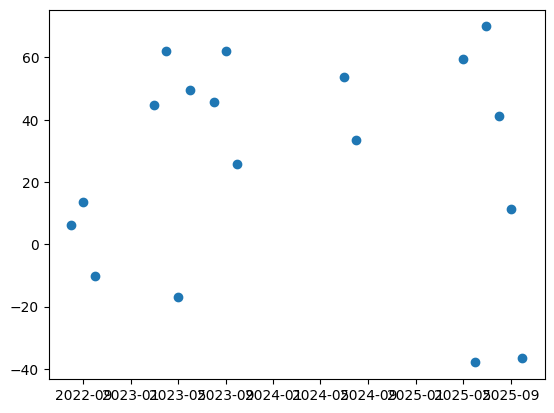

6502.877880331144


In [ ]:
# import matplotlib.pyplot as plt

# temp = nameDataTest[nameDataTest['player_name'] == 'Kershaw, Clayton']
# plt.scatter(temp['period'], temp['residual'])
# plt.show()